# Traffic Sign Detection with YOLOv8 and Attention Mechanisms

This notebook implements and compares two models for traffic sign detection:
1. **Baseline YOLOv8n** - Standard YOLO model
2. **Attention-Enhanced YOLOv8n** - Custom YOLO with CBAM and Self-Attention mechanisms

## Notebook Structure:
- **Part 1:** Data Preparation & Preprocessing
- **Part 2:** Baseline Model Training & Analysis
- **Part 3:** Attention Model Implementation & Training
- **Part 4:** Comprehensive Model Comparison & Evaluation
- **Part 5:** Real-World Testing & Final Recommendations

---

## Part 1: Data Preparation & Preprocessing

### 1.1 Import Required Libraries

In [1]:
import os
import sys
import time
import json
import shutil
import random
from collections import defaultdict, Counter

import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### 1.0 Utility Functions Module

Define reusable functions to avoid code repetition throughout the notebook.

In [ ]:
from scripts.utils import (
    load_training_results,
    print_training_metrics,
    plot_training_metrics,
    compare_training_curves,
    calculate_metrics_lists,
    plot_prediction_comparison,
)

print("Utility functions module loaded!")

Utility functions module loaded!


### 1.2 Define Paths and Create Directory Structure

In [3]:
DATA_ROOT = "/kaggle/input/tt100k-2021/tt100k_2021"
WORK_ROOT = "/kaggle/working/"
OUT_ROOT = f"{WORK_ROOT}tt100k_yolo"

ANN_PATH = os.path.join(DATA_ROOT, "annotations_all.json")

IMG_TRAIN = f"{OUT_ROOT}/images/train"
IMG_VAL = f"{OUT_ROOT}/images/val"
LBL_TRAIN = f"{OUT_ROOT}/labels/train"
LBL_VAL = f"{OUT_ROOT}/labels/val"

for p in [IMG_TRAIN, IMG_VAL, LBL_TRAIN, LBL_VAL]:
    os.makedirs(p, exist_ok=True)

### 1.3 Load and Explore Dataset Annotations

In [4]:
with open(ANN_PATH, "r") as f:
    ann = json.load(f)

imgs = ann["imgs"]
print("Total annotated images:", len(imgs))

Total annotated images: 10592


### 1.4 Extract and Map Class Labels

In [5]:
classes = sorted({obj["category"] for img in imgs.values() for obj in img["objects"]})

class2id = {c: i for i, c in enumerate(classes)}
id2class = {i: c for c, i in class2id.items()}

print("Number of classes:", len(classes))
print(class2id)

Number of classes: 201
{'i1': 0, 'i10': 1, 'i11': 2, 'i12': 3, 'i13': 4, 'i14': 5, 'i15': 6, 'i2': 7, 'i2r': 8, 'i3': 9, 'i4': 10, 'i4l': 11, 'i5': 12, 'il100': 13, 'il110': 14, 'il50': 15, 'il60': 16, 'il70': 17, 'il80': 18, 'il90': 19, 'im': 20, 'ip': 21, 'iz': 22, 'p1': 23, 'p10': 24, 'p11': 25, 'p12': 26, 'p13': 27, 'p14': 28, 'p15': 29, 'p16': 30, 'p17': 31, 'p18': 32, 'p19': 33, 'p1n': 34, 'p2': 35, 'p20': 36, 'p21': 37, 'p23': 38, 'p24': 39, 'p25': 40, 'p26': 41, 'p27': 42, 'p28': 43, 'p29': 44, 'p3': 45, 'p4': 46, 'p5': 47, 'p6': 48, 'p7': 49, 'p8': 50, 'p9': 51, 'pa10': 52, 'pa12': 53, 'pa13': 54, 'pa14': 55, 'pa18': 56, 'pa6': 57, 'pa8': 58, 'pb': 59, 'pbm': 60, 'pbp': 61, 'pc': 62, 'pcd': 63, 'pcl': 64, 'pclr': 65, 'pcr': 66, 'pcs': 67, 'pctl': 68, 'pdd': 69, 'pg': 70, 'ph1.8': 71, 'ph2': 72, 'ph2.1': 73, 'ph2.2': 74, 'ph2.4': 75, 'ph2.5': 76, 'ph2.6': 77, 'ph2.8': 78, 'ph2.9': 79, 'ph3': 80, 'ph3.2': 81, 'ph3.3': 82, 'ph3.5': 83, 'ph3.8': 84, 'ph4': 85, 'ph4.2': 86, 'ph4.3'

### 1.5 Stratified Train/Validation Split

Implement stratified splitting to ensure balanced class distribution in both sets.

In [6]:
# Group images by their primary class (most common class in the image)
class_to_images = defaultdict(list)

for img_id, img_data in imgs.items():
    if not img_data["objects"]:
        continue
    # Get most common class in this image
    class_counts = {}
    for obj in img_data["objects"]:
        cat = obj["category"]
        class_counts[cat] = class_counts.get(cat, 0) + 1
    primary_class = max(class_counts, key=class_counts.get)
    class_to_images[primary_class].append((img_id, img_data))

# Split each class 80/20
train_items_stratified = []
val_items_stratified = []

random.seed(42)
for cls, img_list in class_to_images.items():
    random.shuffle(img_list)
    split = int(0.8 * len(img_list))
    train_items_stratified.extend(img_list[:split])
    val_items_stratified.extend(img_list[split:])

random.shuffle(train_items_stratified)
random.shuffle(val_items_stratified)

print(f"Stratified Train: {len(train_items_stratified)}")
print(f"Stratified Val: {len(val_items_stratified)}")

Stratified Train: 8404
Stratified Val: 2188


### 1.6 Convert Annotations to YOLO Format

Process images and convert bounding box annotations to YOLO format (normalized xywh).

In [7]:
def process_image(img_data, img_root, img_out, lbl_out):
    img_path = os.path.join(img_root, img_data["path"])
    if not os.path.exists(img_path):
        return

    img = Image.open(img_path)
    w, h = img.size

    # copy image
    shutil.copy(img_path, img_out)

    label_path = os.path.join(
        lbl_out, os.path.basename(img_path).replace(".jpg", ".txt")
    )

    with open(label_path, "w") as f:
        for obj in img_data["objects"]:
            cls_id = class2id[obj["category"]]
            b = obj["bbox"]

            xc = ((b["xmin"] + b["xmax"]) / 2) / w
            yc = ((b["ymin"] + b["ymax"]) / 2) / h
            bw = (b["xmax"] - b["xmin"]) / w
            bh = (b["ymax"] - b["ymin"]) / h

            f.write(f"{cls_id} {xc} {yc} {bw} {bh}\n")

In [8]:
for _, img_data in tqdm(train_items_stratified):
    process_image(img_data, DATA_ROOT, IMG_TRAIN, LBL_TRAIN)

for _, img_data in tqdm(val_items_stratified):
    process_image(img_data, DATA_ROOT, IMG_VAL, LBL_VAL)

100%|██████████| 2188/2188 [00:43<00:00, 50.77it/s]


### 1.7 Create YOLO Dataset Configuration

In [9]:
yaml_path = f"{OUT_ROOT}/data.yaml"

names = {i: cid for cid, i in class2id.items()}

yaml_text = f"""
    path: {OUT_ROOT}
    train: images/train
    val: images/val
    
    nc: {len(classes)}
    names: {names}
"""

with open(yaml_path, "w") as f:
    f.write(yaml_text)

print("data.yaml created")

data.yaml created


### 1.8 Verify Label Format

Inspect a sample label file to verify correct YOLO format.

In [10]:
sample_lbl = os.listdir(LBL_TRAIN)[0]
print(open(os.path.join(LBL_TRAIN, sample_lbl)).read())

12 0.35280710449218744 0.4389743896484375 0.014361279296874974 0.018190966796874986
107 0.444271630859375 0.4301875244140625 0.010922167968750007 0.01210649414062498
132 0.460654833984375 0.42949477539062497 0.011564550781250016 0.016061816406249985
134 0.297793505859375 0.44124208984375 0.013479589843749973 0.016981250000000003



---

Train the standard YOLOv8n model with augmentation and optimized hyperparameters.

## Part 2: Baseline Model Training & Analysis

### 2.1 Train Baseline YOLOv8n Model

In [ ]:
model = YOLO("yolov8n.pt")

results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=32,

    # REDUCED augmentation for stability with many classes
    hsv_h=0.005,  # Very minimal color change
    hsv_s=0.3,  # Reduced saturation
    hsv_v=0.2,  # Reduced brightness
    degrees=3,  # Minimal rotation
    translate=0.05,  # Small translation
    scale=0.3,  # Moderate scaling
    fliplr=0.0,  # NO flip for traffic signs
    flipud=0.0,  # NO vertical flip
    mosaic=0.5,  # Reduced mosaic 
    mixup=0.0,  # DISABLED as it can cause issues with imbalanced data
    copy_paste=0.0,  # DISABLED

    optimizer="SGD",
    lr0=0.005,  # REDUCED learning rate for stability
    lrf=0.01,  # Lower final LR
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=5.0,  # Longer warmup
    warmup_momentum=0.8,
    warmup_bias_lr=0.05,  # Reduced

    # Loss weights - INCREASED cls weight for many classes
    box=7.5,
    cls=1.0,  # INCREASED from 0.5 - more focus on classification
    dfl=1.5,

    # Performance
    cache=False,
    device=0,
    workers=4,
    amp=False,

    # Monitoring
    patience=50,
    save_period=10,
    verbose=True,
    plots=True,
    name="train_baseline",
    close_mosaic=20,
)

Ultralytics 8.4.3 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=1.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/tt100k_yolo/data.yaml, degrees=3, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.005, hsv_s=0.3, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=train_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=50, pe

### 2.2 Baseline Model Training Metrics Visualization

Analyze training progression through loss curves, mAP, precision, and recall.

BASELINE MODEL TRAINING METRICS
Total epochs: 100
Final metrics:
  Box Loss: 0.7756
  Class Loss: 0.8232
  DFL Loss: 0.7897
  Val mAP50: 0.5486
  Val mAP50-95: 0.4143


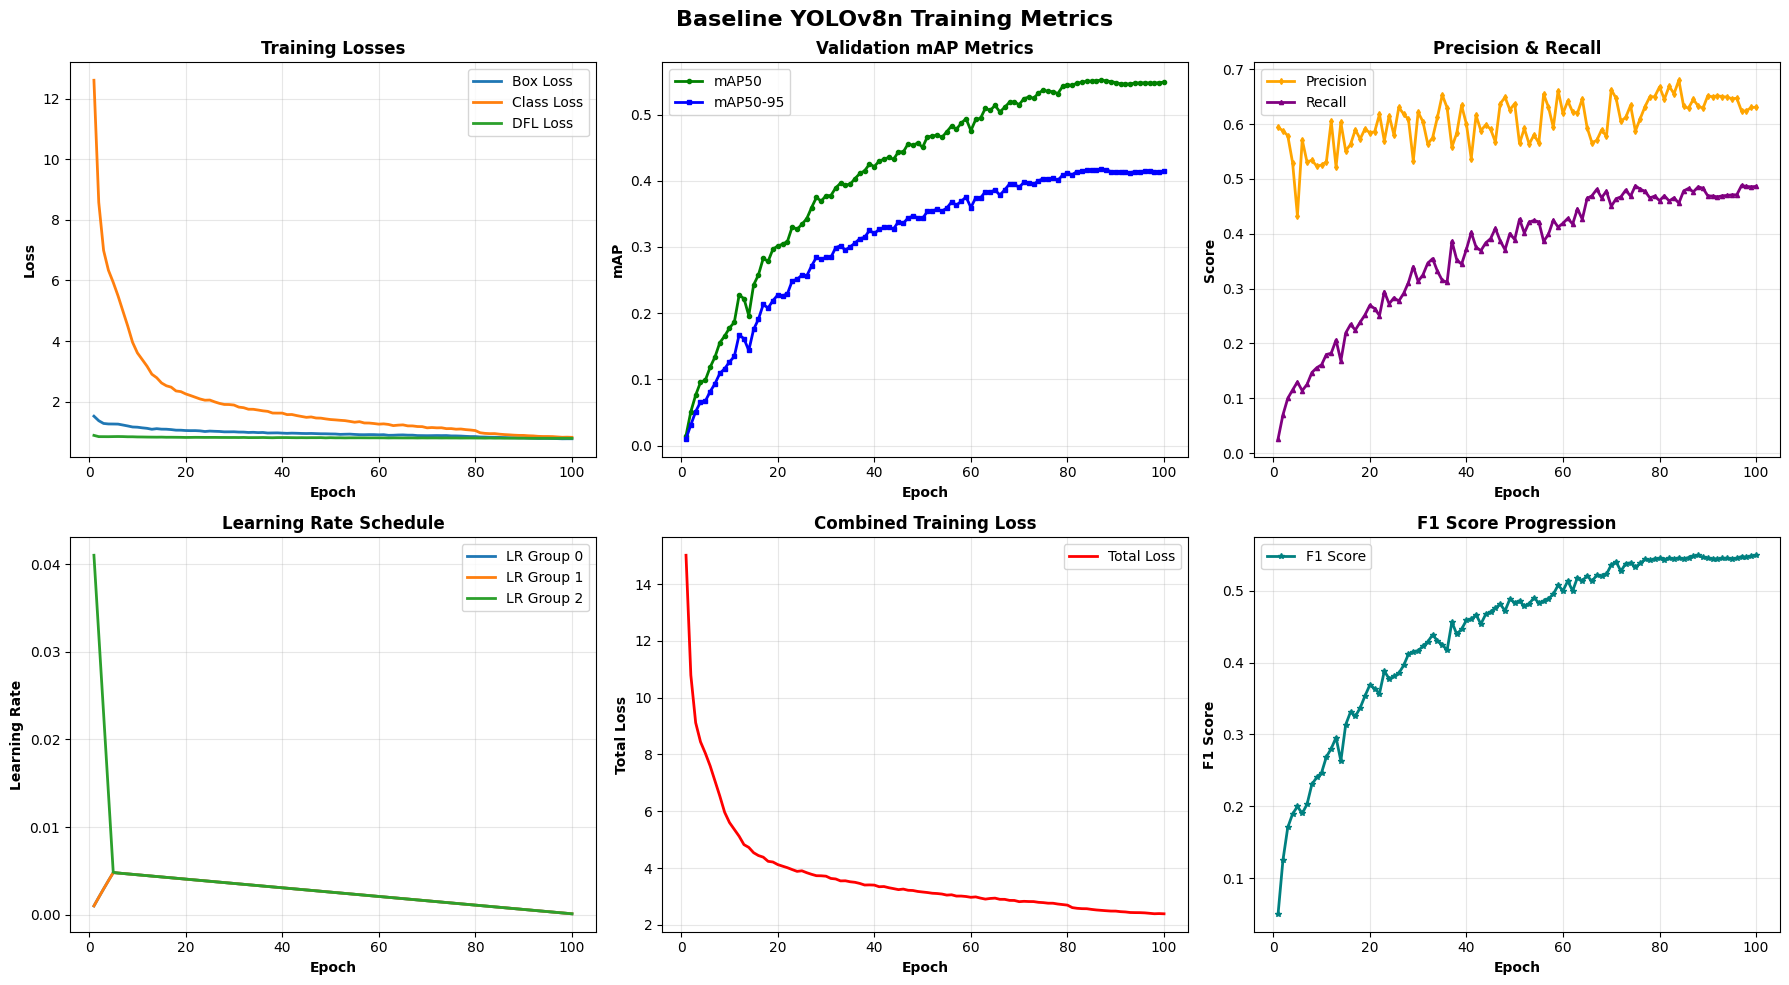


Baseline model training visualization complete!


In [12]:
# Load and visualize baseline training results
baseline_results_path = f"{WORK_ROOT}runs/detect/train_baseline/results.csv"
baseline_results_df = load_training_results(baseline_results_path)

print_training_metrics(baseline_results_df, "BASELINE MODEL")
baseline_total = plot_training_metrics(baseline_results_df, "Baseline YOLOv8n")

print("\nBaseline model training visualization complete!")

### 2.3 Baseline Model Validation Performance

Evaluate the trained baseline model on the validation set.

In [13]:
# Load best model and evaluate
model = YOLO(f"{WORK_ROOT}runs/detect/train_baseline/weights/best.pt")

# Validate on validation set
metrics = model.val(data=yaml_path, split="val")

print(f"\nmAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

# Per-class metrics
print("\nPer-class AP50:")
if hasattr(metrics.box, "ap_class_index"):
    for idx, ap in zip(metrics.box.ap_class_index, metrics.box.ap50):
        class_name = id2class.get(int(idx), f"class_{idx}")
        print(f"  {class_name}: {ap:.4f}")

Ultralytics 8.4.3 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 73 layers, 3,371,327 parameters, 0 gradients, 9.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3849.2±771.7 MB/s, size: 1206.8 KB)
val: Scanning /kaggle/working/tt100k_yolo/labels/val.cache... 2188 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2188/2188 655.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 137/137 4.4it/s 31.2s
                   all       2188       5662      0.645      0.477      0.552      0.417
                    i1          2          2          1      0.964      0.995      0.846
                   i10         14         14      0.679      0.429      0.623       0.45
                   i11          1          1      0.876          1      0.995      0.895
                   i12          3          4      0.708        0.5      0.558      0.459
                   i1

### 2.4 Baseline Performance Analysis: Rare vs Common Classes

Analyze how the baseline model performs on different class frequencies.

Common classes (top 20): 20
Rare classes (bottom 25%): 43

Average AP50 for common classes: 0.8515
Average AP50 for rare classes: 0.3732


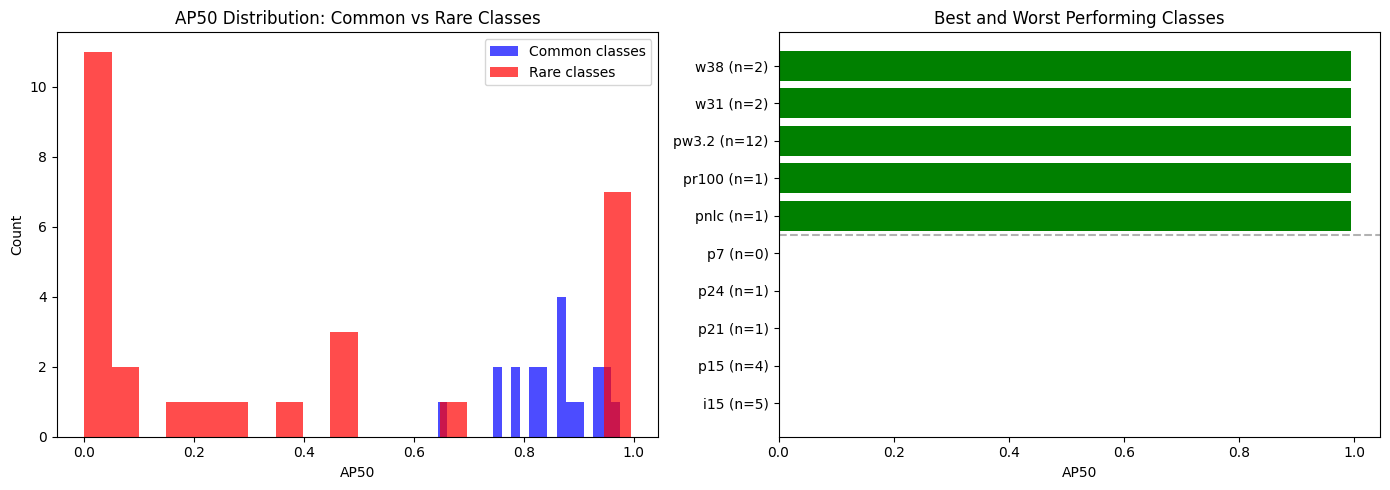


Worst performing classes:
  i15: AP50=0.0000, instances=5
  p15: AP50=0.0000, instances=4
  p21: AP50=0.0000, instances=1
  p24: AP50=0.0000, instances=1
  p7: AP50=0.0000, instances=0

Best performing classes:
  pnlc: AP50=0.9950, instances=1
  pr100: AP50=0.9950, instances=1
  pw3.2: AP50=0.9950, instances=12
  w31: AP50=0.9950, instances=2
  w38: AP50=0.9950, instances=2


In [14]:
# Count instances per class from training labels
class_counts = Counter()
for label_file in os.listdir(LBL_TRAIN):
    with open(os.path.join(LBL_TRAIN, label_file)) as f:
        for line in f:
            cls_id = int(line.split()[0])
            class_counts[cls_id] += 1

# Categorize classes by frequency
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
common_classes = [c for c, cnt in sorted_counts[:20]]  # Top 20
rare_classes = [
    c
    for c, cnt in sorted_counts
    if cnt < np.percentile([c for _, c in sorted_counts], 25)
]

print(f"Common classes (top 20): {len(common_classes)}")
print(f"Rare classes (bottom 25%): {len(rare_classes)}")

# Compare performance
if hasattr(metrics.box, "ap_class_index") and hasattr(metrics.box, "ap50"):
    common_ap = [
        ap
        for idx, ap in zip(metrics.box.ap_class_index, metrics.box.ap50)
        if int(idx) in common_classes
    ]
    rare_ap = [
        ap
        for idx, ap in zip(metrics.box.ap_class_index, metrics.box.ap50)
        if int(idx) in rare_classes
    ]

    print(f"\nAverage AP50 for common classes: {np.mean(common_ap):.4f}")
    print(f"Average AP50 for rare classes: {np.mean(rare_ap):.4f}")

    # Visualize
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    ax[0].hist(common_ap, bins=20, alpha=0.7, label="Common classes", color="blue")
    ax[0].hist(rare_ap, bins=20, alpha=0.7, label="Rare classes", color="red")
    ax[0].set_xlabel("AP50")
    ax[0].set_ylabel("Count")
    ax[0].set_title("AP50 Distribution: Common vs Rare Classes")
    ax[0].legend()

    # Top and bottom performers
    all_results = [
        (int(idx), ap, id2class.get(int(idx), f"cls_{idx}"), class_counts[int(idx)])
        for idx, ap in zip(metrics.box.ap_class_index, metrics.box.ap50)
    ]
    all_results.sort(key=lambda x: x[1])

    worst_5 = all_results[:5]
    best_5 = all_results[-5:]

    ax[1].barh(
        range(10), [x[1] for x in worst_5 + best_5], color=["red"] * 5 + ["green"] * 5
    )
    ax[1].set_yticks(range(10))
    ax[1].set_yticklabels([f"{x[2]} (n={x[3]})" for x in worst_5 + best_5])
    ax[1].set_xlabel("AP50")
    ax[1].set_title("Best and Worst Performing Classes")
    ax[1].axhline(4.5, color="black", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nWorst performing classes:")
    for cls_id, ap, name, count in worst_5:
        print(f"  {name}: AP50={ap:.4f}, instances={count}")

    print("\nBest performing classes:")
    for cls_id, ap, name, count in best_5:
        print(f"  {name}: AP50={ap:.4f}, instances={count}")

---

## 3: Attention-Enhanced Model Implementation & Training

Implement CBAM (Channel + Spatial Attention) mechanisms.

### 3.1 Attention Mechanism Modules

In [ ]:
import torch
import torch.nn as nn
from ultralytics import YOLO


class ChannelAttention(nn.Module):
    """Channel attention component of CBAM"""

    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    """Spatial attention component of CBAM"""

    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x))


class CBAM(nn.Module):

    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x

### 3.2 Add CBAM to YOLO

In [ ]:
def add_cbam_to_yolo(model, verbose=True):
    """
    Adds CBAM attention modules to YOLOv8 backbone
    """

    # Target positions: After C2f blocks in backbone
    # YOLOv8n backbone structure:
    # 0: Conv, 1: Conv, 2: C2f, 3: Conv, 4: C2f, 5: Conv, 6: C2f, 7: Conv, 8: C2f, 9: SPPF
    target_layers = [2, 4, 6, 8]  # After each C2f block

    injected_count = 0

    for idx in target_layers:
        try:
            layer = model.model.model[idx]

            # Get output channels
            if hasattr(layer, "cv2"):
                channels = layer.cv2.conv.out_channels
            elif hasattr(layer, "conv"):
                channels = layer.conv.out_channels
            else:
                continue

            # Create CBAM module
            cbam = CBAM(channels, reduction=16)

            # Wrap original layer with CBAM
            model.model.model[idx] = nn.Sequential(layer, cbam)

            injected_count += 1

            if verbose:
                print(f"Added CBAM at layer {idx} ({channels} channels)")

        except Exception as e:
            if verbose:
                print(f"Failed at layer {idx}: {e}")

    if verbose:
        print(f"\nTotal CBAM modules injected: {injected_count}")

        # Count parameters
        total_params = sum(p.numel() for p in model.model.parameters())
        print(f"Total parameters: {total_params:,} ({total_params/1e6:.2f}M)")

    return model

### 3.3 Train Attention Based YOLOv8n Model

Define YOLO architecture with integrated attention mechanisms in backbone and neck.
Train with the same hyperparameters as of baseline model.

In [ ]:
model = YOLO("yolov8n.pt")

model = add_cbam_to_yolo(model, verbose=True)

results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=32,

    # REDUCED augmentation for stability with many classes
    hsv_h=0.005,
    hsv_s=0.3,
    hsv_v=0.2,
    degrees=3,
    translate=0.05,
    scale=0.3,
    fliplr=0.0,
    flipud=0.0,
    mosaic=0.5,
    mixup=0.0,
    copy_paste=0.0,
    optimizer="SGD",
    lr0=0.005,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=5.0,
    warmup_momentum=0.8,
    warmup_bias_lr=0.05,

    box=7.5,
    cls=1.0,
    dfl=1.5,

    # Performance
    cache=False,
    device=0,
    workers=4,
    amp=False,

    # Monitoring
    patience=20,
    save_period=10,
    verbose=True,
    plots=True,
    name="train_attention",
    close_mosaic=10,
)

Added CBAM at layer 2 (32 channels)
Added CBAM at layer 4 (64 channels)
Added CBAM at layer 6 (128 channels)
Added CBAM at layer 8 (256 channels)

Total CBAM modules injected: 4
Total parameters: 3,168,472 (3.17M)
Ultralytics 8.4.3 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/tt100k_yolo/data.yaml, degrees=3, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.005, hsv_s=0.3, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, ma

### 3.4 Attention Model Training Metrics Visualization

Analyze attention model training progression.

ATTENTION MODEL TRAINING METRICS
Total epochs: 100
Final metrics:
  Box Loss: 0.8253
  Class Loss: 0.9714
  DFL Loss: 0.7968
  Val mAP50: 0.5197
  Val mAP50-95: 0.3913


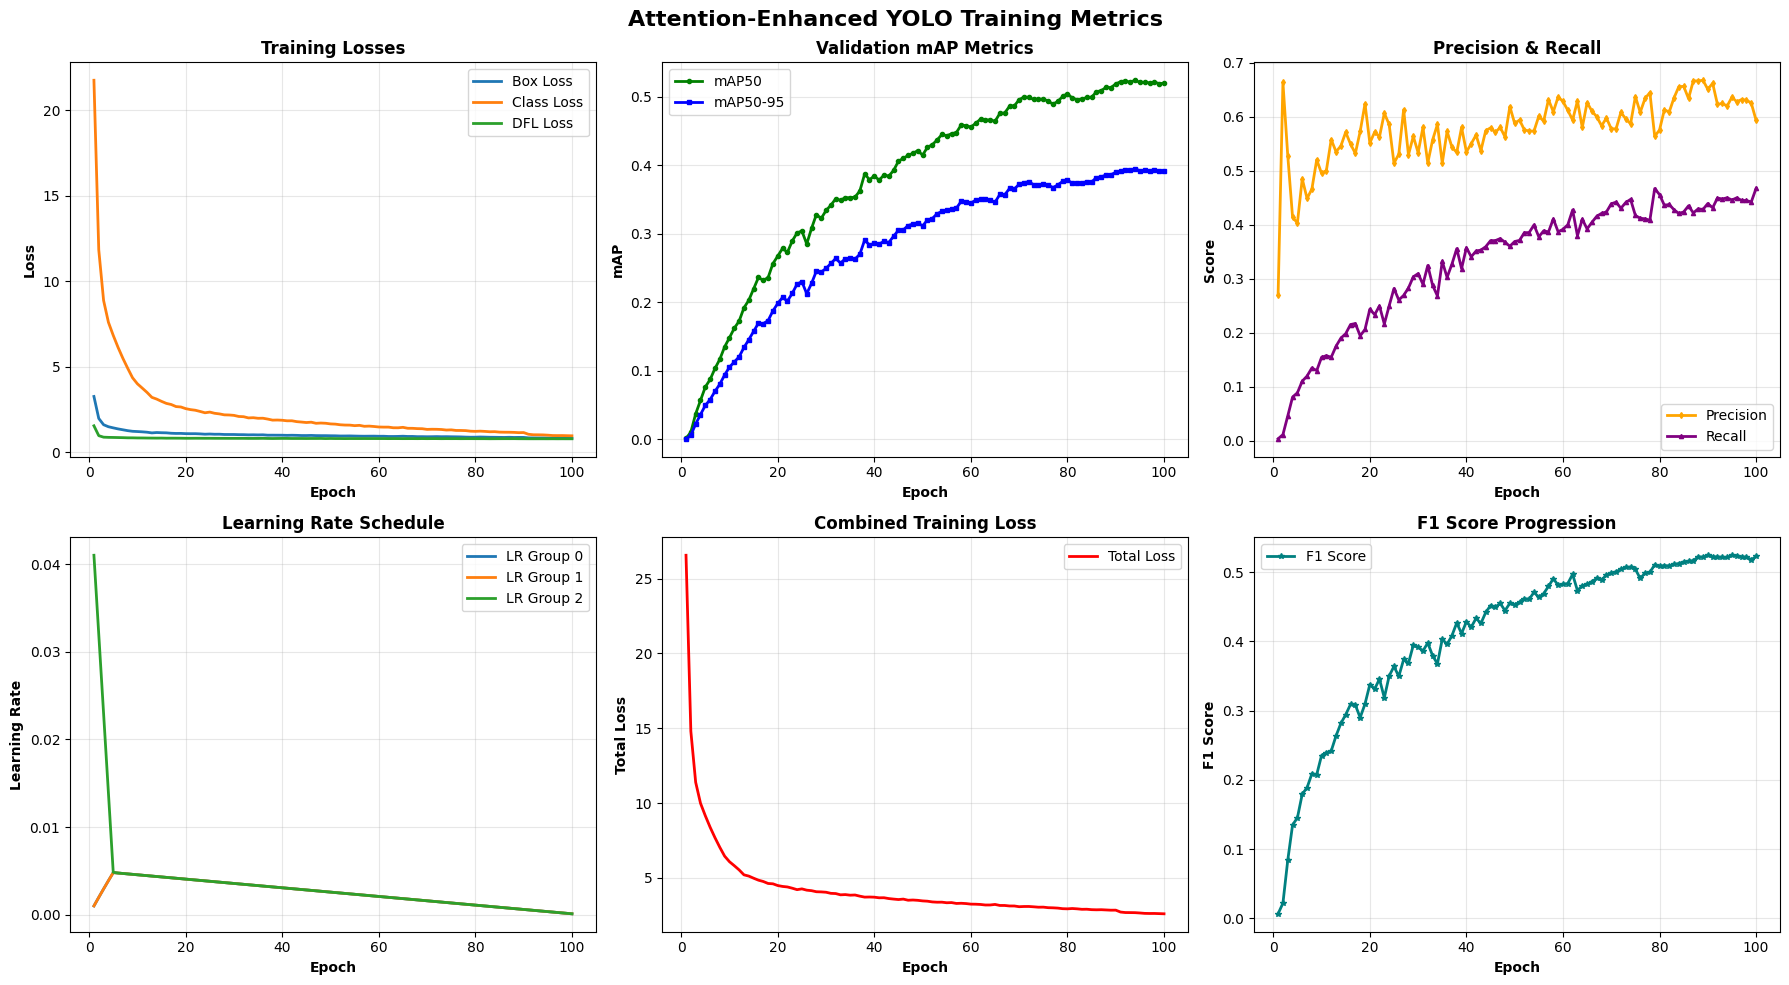


Attention model training visualization complete!


In [18]:
# Load and visualize attention training results
attention_results_path = f"{WORK_ROOT}runs/detect/train_attention/results.csv"
attention_results_df = load_training_results(attention_results_path)

print_training_metrics(attention_results_df, "ATTENTION MODEL")
attention_total = plot_training_metrics(attention_results_df, "Attention-Enhanced YOLO")

print("\nAttention model training visualization complete!")

---
## 4. Model Comparison

### 4.1 Training Curves Comparison: Baseline vs Attention

Compare training progression between both models.

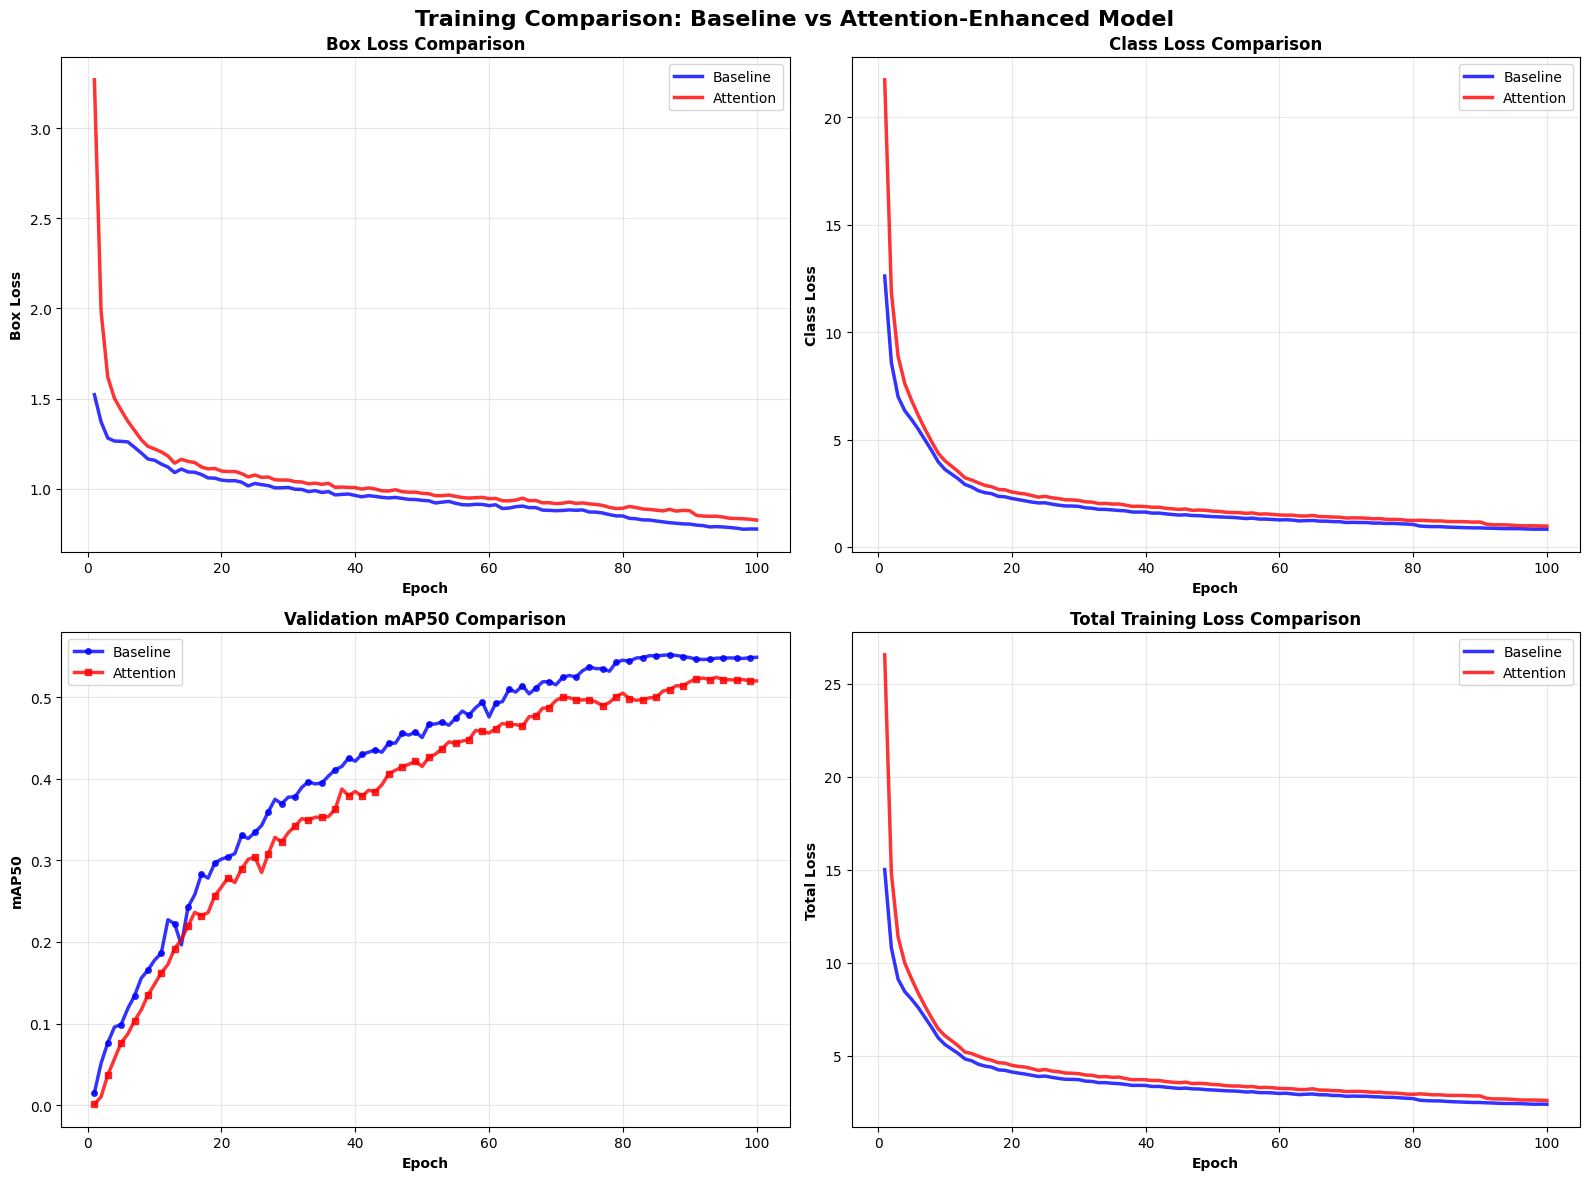

TRAINING CONVERGENCE SUMMARY

Final mAP50:
  Baseline:  0.5486
  Attention: 0.5197
  Difference: -0.0289 (-5.27%)

Final Total Loss:
  Baseline:  2.3885
  Attention: 2.5935
  Difference: 0.2050 (+8.58%)

Best Performance Epochs:
  Baseline:  Epoch 86 (mAP50: 0.5517)
  Attention: Epoch 93 (mAP50: 0.5242)


In [19]:
# Compare training curves between both models
compare_training_curves(baseline_results_df, attention_results_df)

# Print comparative summary
print("TRAINING CONVERGENCE SUMMARY")

baseline_final_map = baseline_results_df['metrics/mAP50(B)'].iloc[-1]
attention_final_map = attention_results_df['metrics/mAP50(B)'].iloc[-1]

baseline_final_loss = baseline_total.iloc[-1]
attention_final_loss = attention_total.iloc[-1]

print(f"\nFinal mAP50:")
print(f"  Baseline:  {baseline_final_map:.4f}")
print(f"  Attention: {attention_final_map:.4f}")
print(f"  Difference: {(attention_final_map - baseline_final_map):.4f} ({((attention_final_map - baseline_final_map) / baseline_final_map * 100):+.2f}%)")

print(f"\nFinal Total Loss:")
print(f"  Baseline:  {baseline_final_loss:.4f}")
print(f"  Attention: {attention_final_loss:.4f}")
print(f"  Difference: {(attention_final_loss - baseline_final_loss):.4f} ({((attention_final_loss - baseline_final_loss) / baseline_final_loss * 100):+.2f}%)")

# Find best epochs
baseline_best_epoch = baseline_results_df['metrics/mAP50(B)'].idxmax()
attention_best_epoch = attention_results_df['metrics/mAP50(B)'].idxmax()

print(f"\nBest Performance Epochs:")
print(f"  Baseline:  Epoch {baseline_best_epoch} (mAP50: {baseline_results_df['metrics/mAP50(B)'].iloc[baseline_best_epoch]:.4f})")
print(f"  Attention: Epoch {attention_best_epoch} (mAP50: {attention_results_df['metrics/mAP50(B)'].iloc[attention_best_epoch]:.4f})")

### 4.2 Training Completion Summary

Both models trained successfully - ready for comprehensive evaluation.

In [20]:
print(" " * 35 + "TRAINING COMPLETED")

print("\nBoth models have been successfully trained!")
print("\nTraining Summary:\n")

print("1. BASELINE YOLOv8n MODEL")
print(f"   Location: {WORK_ROOT}runs/detect/train_baseline/weights/best.pt")
print(f"   Epochs completed: {len(baseline_results_df)}")
print(f"   Final training loss: {baseline_total.iloc[-1]:.4f}")
print(f"   Final validation mAP50: {baseline_results_df['metrics/mAP50(B)'].iloc[-1]:.4f}")
print(f"   Final validation mAP50-95: {baseline_results_df['metrics/mAP50-95(B)'].iloc[-1]:.4f}")
print(f"   Best mAP50: {baseline_results_df['metrics/mAP50(B)'].max():.4f} (Epoch {baseline_results_df['metrics/mAP50(B)'].idxmax()})")

print("\n2. ATTENTION-ENHANCED YOLO MODEL")
print(f"   Location: {WORK_ROOT}runs/detect/train_attention/weights/best.pt")
print(f"   Epochs completed: {len(attention_results_df)}")
print(f"   Final training loss: {attention_total.iloc[-1]:.4f}")
print(f"   Final validation mAP50: {attention_results_df['metrics/mAP50(B)'].iloc[-1]:.4f}")
print(f"   Final validation mAP50-95: {attention_results_df['metrics/mAP50-95(B)'].iloc[-1]:.4f}")
print(f"   Best mAP50: {attention_results_df['metrics/mAP50(B)'].max():.4f} (Epoch {attention_results_df['metrics/mAP50(B)'].idxmax()})")

                                   TRAINING COMPLETED

Both models have been successfully trained!

Training Summary:

1. BASELINE YOLOv8n MODEL
   Location: /kaggle/working/runs/detect/train_baseline/weights/best.pt
   Epochs completed: 100
   Final training loss: 2.3885
   Final validation mAP50: 0.5486
   Final validation mAP50-95: 0.4143
   Best mAP50: 0.5517 (Epoch 86)

2. ATTENTION-ENHANCED YOLO MODEL
   Location: /kaggle/working/runs/detect/train_attention/weights/best.pt
   Epochs completed: 100
   Final training loss: 2.5935
   Final validation mAP50: 0.5197
   Final validation mAP50-95: 0.3913
   Best mAP50: 0.5242 (Epoch 93)


### 4.3 Validation Performance Metrics

In [ ]:
# Load both models
model_baseline = YOLO(f"{WORK_ROOT}runs/detect/train_baseline/weights/best.pt")
model_attention = YOLO(f"{WORK_ROOT}runs/detect/train_attention/weights/best.pt")

print("MODEL COMPARISON: Baseline YOLOv8n vs Attention-Enhanced YOLOv8n")

# Evaluate both models on validation set
print("\nEvaluating Baseline Model...")
metrics_baseline = model_baseline.val(data=yaml_path, split="val")

print("\nEvaluating Attention-Enhanced Model...")
metrics_attention = model_attention.val(data=yaml_path, split="val")

# Create comparison dictionary
comparison = {
    'Metric': ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1-Score'],
    'Baseline': [
        metrics_baseline.box.map50,
        metrics_baseline.box.map,
        metrics_baseline.box.mp,
        metrics_baseline.box.mr,
        2 * (metrics_baseline.box.mp * metrics_baseline.box.mr) / (metrics_baseline.box.mp + metrics_baseline.box.mr + 1e-6)
    ],
    'Attention': [
        metrics_attention.box.map50,
        metrics_attention.box.map,
        metrics_attention.box.mp,
        metrics_attention.box.mr,
        2 * (metrics_attention.box.mp * metrics_attention.box.mr) / (metrics_attention.box.mp + metrics_attention.box.mr + 1e-6)
    ]
}

# Calculate improvements
comparison['Improvement (%)'] = [
    ((att - base) / base * 100) if base > 0 else 0
    for base, att in zip(comparison['Baseline'], comparison['Attention'])
]

# Display comparison table
print("OVERALL METRICS COMPARISON")
for i, metric in enumerate(comparison['Metric']):
    base_val = comparison['Baseline'][i]
    att_val = comparison['Attention'][i]
    imp_val = comparison['Improvement (%)'][i]
    
    improvement_sign = "↑" if imp_val > 0 else "↓" if imp_val < 0 else "→"
    print(f"{metric:12s}: Baseline={base_val:.4f} | Attention={att_val:.4f} | {improvement_sign} {imp_val:+.2f}%")

MODEL COMPARISON: Baseline YOLOv8n vs Attention-Enhanced YOLOv8n

Evaluating Baseline Model...
Ultralytics 8.4.3 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 73 layers, 3,371,327 parameters, 0 gradients, 9.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3516.1±319.5 MB/s, size: 1420.6 KB)
val: Scanning /kaggle/working/tt100k_yolo/labels/val.cache... 2188 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2188/2188 655.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 137/137 4.6it/s 29.6s
                   all       2188       5662      0.645      0.477      0.552      0.417
                    i1          2          2          1      0.964      0.995      0.846
                   i10         14         14      0.679      0.429      0.623       0.45
                   i11          1          1      0.876          1      0.995      0.895
               

### 4.4 Per-Class Performance Analysis

Detailed analysis of how attention mechanisms affect each class.

In [22]:
# Per-class comparison
if hasattr(metrics_baseline.box, 'ap_class_index') and hasattr(metrics_attention.box, 'ap_class_index'):
    # Create per-class comparison
    class_improvements = []
    
    baseline_aps = dict(zip(
        [int(idx) for idx in metrics_baseline.box.ap_class_index],
        metrics_baseline.box.ap50
    ))
    attention_aps = dict(zip(
        [int(idx) for idx in metrics_attention.box.ap_class_index],
        metrics_attention.box.ap50
    ))
    
    for cls_id in baseline_aps.keys():
        if cls_id in attention_aps:
            base_ap = baseline_aps[cls_id]
            att_ap = attention_aps[cls_id]
            improvement = ((att_ap - base_ap) / base_ap * 100) if base_ap > 0 else 0
            class_name = id2class.get(cls_id, f"class_{cls_id}")
            class_count = class_counts.get(cls_id, 0)
            
            class_improvements.append({
                'class_id': cls_id,
                'class_name': class_name,
                'count': class_count,
                'baseline_ap': base_ap,
                'attention_ap': att_ap,
                'improvement': improvement
            })
    
    # Sort by improvement
    class_improvements.sort(key=lambda x: x['improvement'], reverse=True)
    
    print("TOP 10 MOST IMPROVED CLASSES")
    print(f"{'Class Name':<25} {'Instances':<12} {'Baseline AP':<15} {'Attention AP':<15} {'Improvement':<15}")
    
    for item in class_improvements[:10]:
        print(f"{item['class_name']:<25} {item['count']:<12} {item['baseline_ap']:<15.4f} {item['attention_ap']:<15.4f} {item['improvement']:+.2f}%")
    
    print("TOP 10 MOST DEGRADED CLASSES")
    print(f"{'Class Name':<25} {'Instances':<12} {'Baseline AP':<15} {'Attention AP':<15} {'Improvement':<15}")
    
    for item in class_improvements[-10:]:
        print(f"{item['class_name']:<25} {item['count']:<12} {item['baseline_ap']:<15.4f} {item['attention_ap']:<15.4f} {item['improvement']:+.2f}%")
    
    # Statistics
    improvements_list = [x['improvement'] for x in class_improvements]
    positive_improvements = [x for x in improvements_list if x > 0]
    negative_improvements = [x for x in improvements_list if x < 0]
    
    print("IMPROVEMENT STATISTICS")
    print(f"Classes improved: {len(positive_improvements)} ({len(positive_improvements)/len(improvements_list)*100:.1f}%)")
    print(f"Classes degraded: {len(negative_improvements)} ({len(negative_improvements)/len(improvements_list)*100:.1f}%)")
    print(f"Average improvement: {np.mean(improvements_list):.2f}%")
    print(f"Median improvement: {np.median(improvements_list):.2f}%")
    print(f"Max improvement: {np.max(improvements_list):.2f}%")
    print(f"Max degradation: {np.min(improvements_list):.2f}%")

TOP 10 MOST IMPROVED CLASSES
Class Name                Instances    Baseline AP     Attention AP    Improvement    
w37                       2            0.0127          0.2513          +1873.61%
w50                       2            0.0829          0.9950          +1100.00%
w18                       8            0.0140          0.0818          +484.63%
ph2.5                     10           0.0054          0.0237          +340.09%
pm50                      8            0.0876          0.2132          +143.45%
w8                        5            0.2518          0.5950          +136.28%
pm40                      6            0.2497          0.5783          +131.61%
ph3.5                     6            0.0408          0.0869          +113.34%
pm46                      5            0.0343          0.0711          +107.14%
pn-2                      4            0.4975          0.9950          +100.00%
TOP 10 MOST DEGRADED CLASSES
Class Name                Instances    Baseline AP   

### 4.5 Visual Performance Comparison

Comprehensive visualizations comparing both models across multiple dimensions.

/tmp/ipykernel_31/3227495963.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,


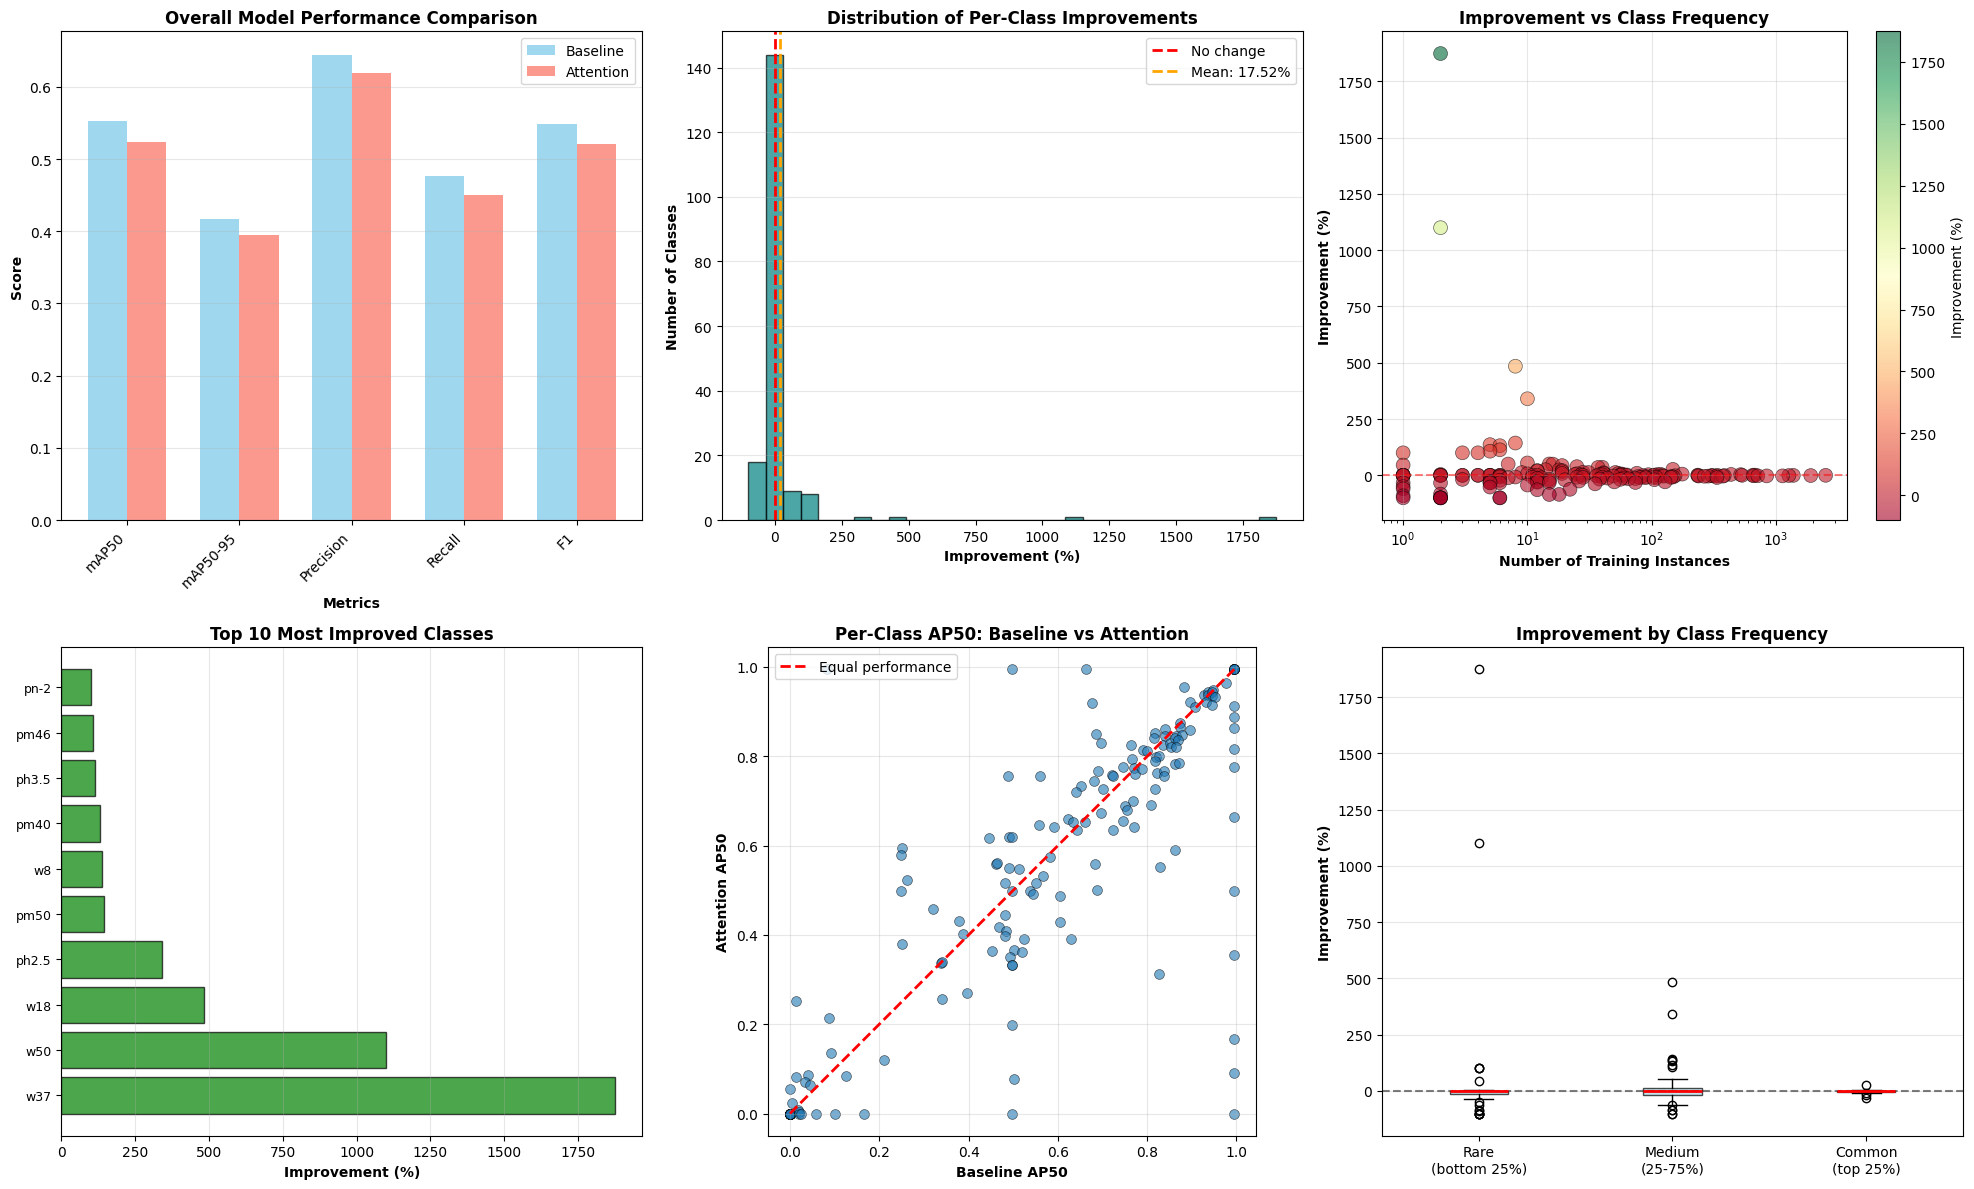


Visualization complete!


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Overall Metrics Comparison
ax = axes[0, 0]
metrics_names = ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1']
x_pos = np.arange(len(metrics_names))
width = 0.35

baseline_values = [
    metrics_baseline.box.map50,
    metrics_baseline.box.map,
    metrics_baseline.box.mp,
    metrics_baseline.box.mr,
    2 * (metrics_baseline.box.mp * metrics_baseline.box.mr) / (metrics_baseline.box.mp + metrics_baseline.box.mr + 1e-6)
]

attention_values = [
    metrics_attention.box.map50,
    metrics_attention.box.map,
    metrics_attention.box.mp,
    metrics_attention.box.mr,
    2 * (metrics_attention.box.mp * metrics_attention.box.mr) / (metrics_attention.box.mp + metrics_attention.box.mr + 1e-6)
]

ax.bar(x_pos - width/2, baseline_values, width, label='Baseline', color='skyblue', alpha=0.8)
ax.bar(x_pos + width/2, attention_values, width, label='Attention', color='salmon', alpha=0.8)
ax.set_xlabel('Metrics', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Overall Model Performance Comparison', fontweight='bold', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. Improvement Distribution
ax = axes[0, 1]
if class_improvements:
    improvements = [x['improvement'] for x in class_improvements]
    ax.hist(improvements, bins=30, color='teal', alpha=0.7, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
    ax.axvline(np.mean(improvements), color='orange', linestyle='--', linewidth=2, label=f'Mean: {np.mean(improvements):.2f}%')
    ax.set_xlabel('Improvement (%)', fontweight='bold')
    ax.set_ylabel('Number of Classes', fontweight='bold')
    ax.set_title('Distribution of Per-Class Improvements', fontweight='bold', fontsize=12)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# 3. Improvement vs Class Frequency
ax = axes[0, 2]
if class_improvements:
    counts = [x['count'] for x in class_improvements]
    improvements = [x['improvement'] for x in class_improvements]
    scatter = ax.scatter(counts, improvements, c=improvements, cmap='RdYlGn', 
                        s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Number of Training Instances', fontweight='bold')
    ax.set_ylabel('Improvement (%)', fontweight='bold')
    ax.set_title('Improvement vs Class Frequency', fontweight='bold', fontsize=12)
    ax.set_xscale('log')
    plt.colorbar(scatter, ax=ax, label='Improvement (%)')
    ax.grid(True, alpha=0.3)

# 4. Top Improved Classes
ax = axes[1, 0]
if class_improvements:
    top_improved = class_improvements[:10]
    names = [x['class_name'][:20] for x in top_improved]
    imps = [x['improvement'] for x in top_improved]
    colors = ['green' if x > 0 else 'red' for x in imps]
    
    y_pos = np.arange(len(names))
    ax.barh(y_pos, imps, color=colors, alpha=0.7, edgecolor='black')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('Improvement (%)', fontweight='bold')
    ax.set_title('Top 10 Most Improved Classes', fontweight='bold', fontsize=12)
    ax.axvline(0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(axis='x', alpha=0.3)

# 5. AP Comparison Scatter
ax = axes[1, 1]
if class_improvements:
    baseline_aps_list = [x['baseline_ap'] for x in class_improvements]
    attention_aps_list = [x['attention_ap'] for x in class_improvements]
    
    ax.scatter(baseline_aps_list, attention_aps_list, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    
    # Diagonal line (y=x)
    max_val = max(max(baseline_aps_list), max(attention_aps_list))
    ax.plot([0, max_val], [0, max_val], 'r--', label='Equal performance', linewidth=2)
    
    ax.set_xlabel('Baseline AP50', fontweight='bold')
    ax.set_ylabel('Attention AP50', fontweight='bold')
    ax.set_title('Per-Class AP50: Baseline vs Attention', fontweight='bold', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

# 6. Rare vs Common Class Performance
ax = axes[1, 2]
if class_improvements:
    # Categorize by frequency
    rare_improvements = [x['improvement'] for x in class_improvements if x['count'] < np.percentile([y['count'] for y in class_improvements], 25)]
    common_improvements = [x['improvement'] for x in class_improvements if x['count'] >= np.percentile([y['count'] for y in class_improvements], 75)]
    medium_improvements = [x['improvement'] for x in class_improvements if np.percentile([y['count'] for y in class_improvements], 25) <= x['count'] < np.percentile([y['count'] for y in class_improvements], 75)]
    
    data_to_plot = [rare_improvements, medium_improvements, common_improvements]
    labels = ['Rare\n(bottom 25%)', 'Medium\n(25-75%)', 'Common\n(top 25%)']
    
    bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_ylabel('Improvement (%)', fontweight='bold')
    ax.set_title('Improvement by Class Frequency', fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisualization complete!")

### 4.6 Side-by-Side Prediction Comparison

Compare actual detection outputs from both models on same images.

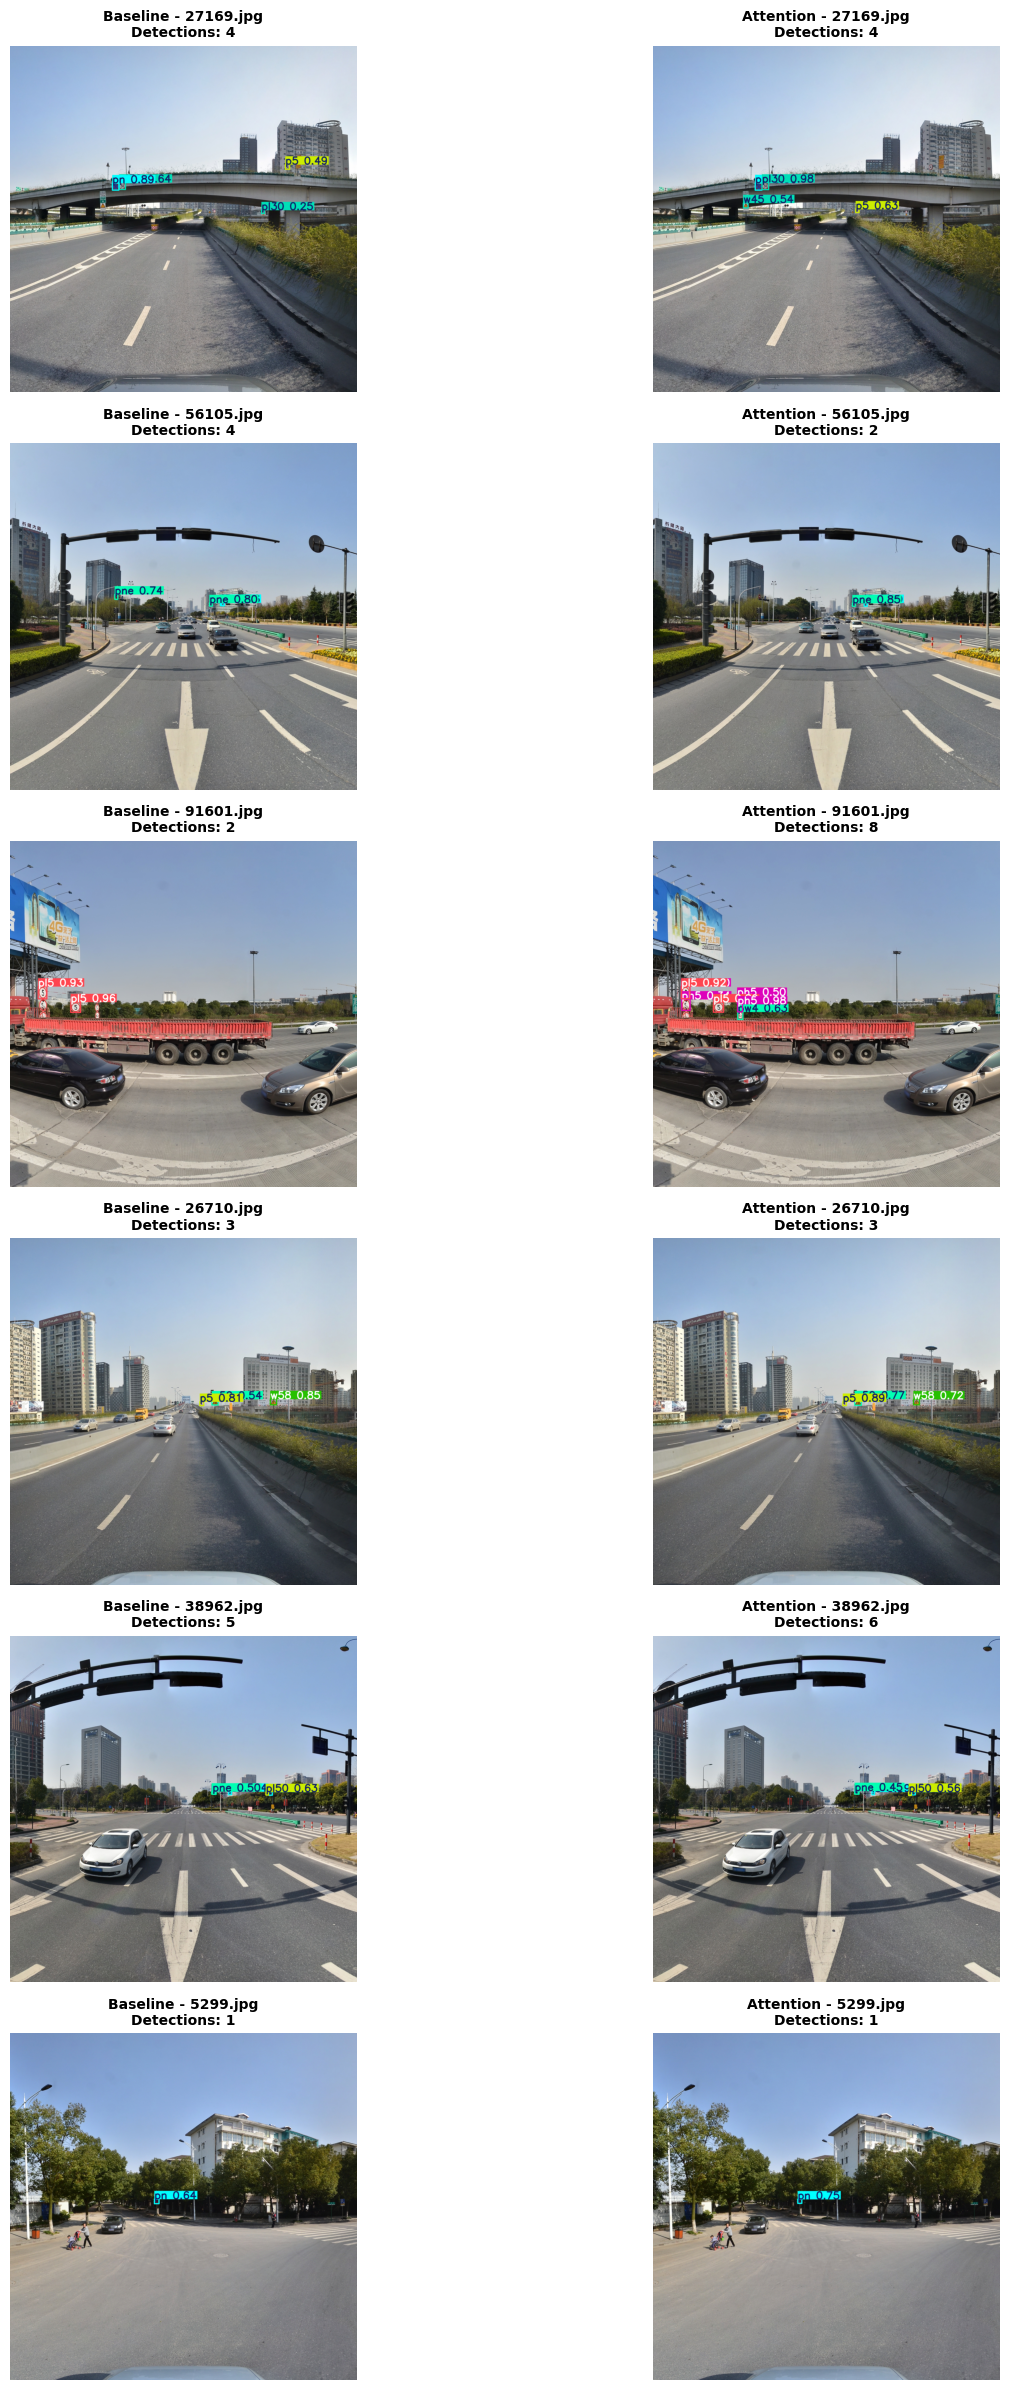

 Prediction comparison complete!


In [24]:
# Compare predictions on validation images
val_images = [os.path.join(IMG_VAL, f) for f in os.listdir(IMG_VAL)[:6]]
plot_prediction_comparison(model_baseline, model_attention, val_images, 'Baseline', 'Attention', max_images=6)

print(" Prediction comparison complete!")

### 4.7 Computational Efficiency Analysis

Compare model size and inference speed.

MODEL SIZE COMPARISON
Baseline model size: 6.67 MB
Attention model size: 6.67 MB
Size increase: 0.00 MB (+0.00%)
INFERENCE SPEED COMPARISON (50 images)
Baseline inference time: 1.772 seconds (35.45 ms/image)
Attention inference time: 1.779 seconds (35.59 ms/image)
Speed difference: +0.40%
Baseline FPS: 28.21
Attention FPS: 28.10


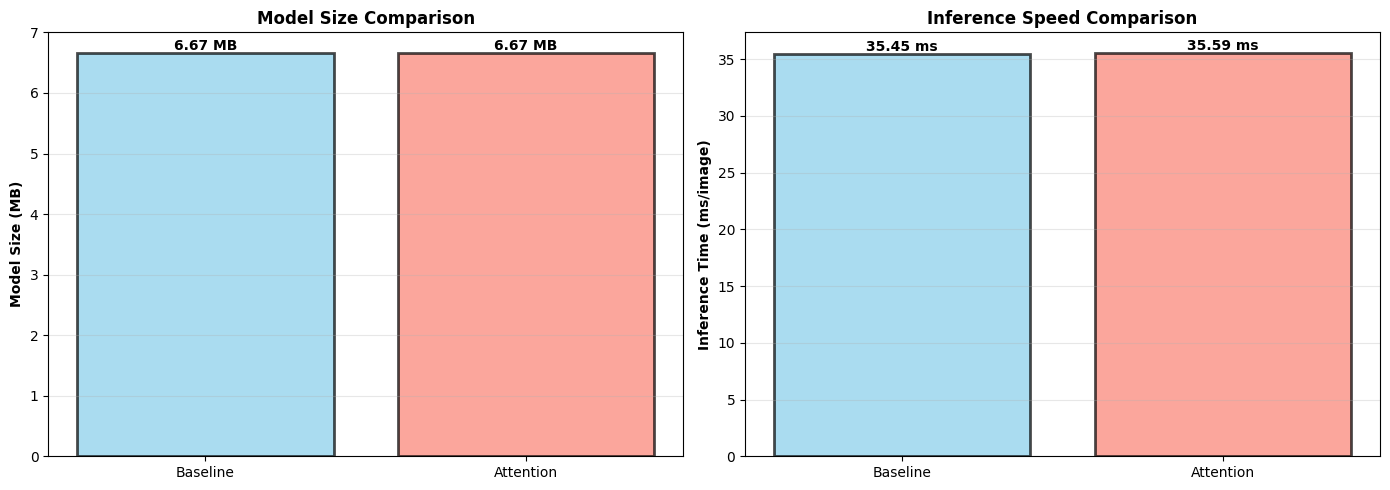

In [25]:
# Model size comparison
baseline_size = os.path.getsize(f"{WORK_ROOT}runs/detect/train_baseline/weights/best.pt") / (1024 * 1024)  # MB
attention_size = os.path.getsize(f"{WORK_ROOT}runs/detect/train_attention/weights/best.pt") / (1024 * 1024)  # MB

print("MODEL SIZE COMPARISON")
print(f"Baseline model size: {baseline_size:.2f} MB")
print(f"Attention model size: {attention_size:.2f} MB")
print(f"Size increase: {(attention_size - baseline_size):.2f} MB ({((attention_size/baseline_size - 1) * 100):+.2f}%)")

# Inference speed comparison
test_images = [os.path.join(IMG_VAL, f) for f in os.listdir(IMG_VAL)[:50]]

print("INFERENCE SPEED COMPARISON (50 images)")

# Baseline inference time
start_time = time.time()
for img_path in test_images:
    _ = model_baseline.predict(img_path, conf=0.25, verbose=False)
baseline_time = time.time() - start_time

# Attention inference time
start_time = time.time()
for img_path in test_images:
    _ = model_attention.predict(img_path, conf=0.25, verbose=False)
attention_time = time.time() - start_time

print(f"Baseline inference time: {baseline_time:.3f} seconds ({baseline_time/50*1000:.2f} ms/image)")
print(f"Attention inference time: {attention_time:.3f} seconds ({attention_time/50*1000:.2f} ms/image)")
print(f"Speed difference: {((attention_time/baseline_time - 1) * 100):+.2f}%")
print(f"Baseline FPS: {50/baseline_time:.2f}")
print(f"Attention FPS: {50/attention_time:.2f}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Size comparison
ax = axes[0]
models = ['Baseline', 'Attention']
sizes = [baseline_size, attention_size]
colors = ['skyblue', 'salmon']
bars = ax.bar(models, sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Model Size (MB)', fontweight='bold')
ax.set_title('Model Size Comparison', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{size:.2f} MB',
            ha='center', va='bottom', fontweight='bold')

# Speed comparison
ax = axes[1]
times = [baseline_time/50*1000, attention_time/50*1000]
bars = ax.bar(models, times, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Inference Time (ms/image)', fontweight='bold')
ax.set_title('Inference Speed Comparison', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, time_val in zip(bars, times):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{time_val:.2f} ms',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

---

## 5: Final Recommendations

### 5.1 Final Summary & Deployment Recommendations

Comprehensive summary and actionable recommendations based on all results.

In [27]:
print(" " * 35 + "FINAL SUMMARY")

print("\n PERFORMANCE SUMMARY:")

# Overall metrics
print(f"\n1. Overall Detection Performance:")
print(f"   • Baseline mAP50: {metrics_baseline.box.map50:.4f}")
print(f"   • Attention mAP50: {metrics_attention.box.map50:.4f}")
print(
    f"   • Improvement: {((metrics_attention.box.map50 - metrics_baseline.box.map50) / metrics_baseline.box.map50 * 100):+.2f}%"
)

print(f"\n2. Precision & Recall:")
print(
    f"   • Baseline Precision: {metrics_baseline.box.mp:.4f} | Recall: {metrics_baseline.box.mr:.4f}"
)
print(
    f"   • Attention Precision: {metrics_attention.box.mp:.4f} | Recall: {metrics_attention.box.mr:.4f}"
)

# Model efficiency
print(f"\n3. Model Efficiency:")
print(
    f"   • Size increase: {((attention_size/baseline_size - 1) * 100):+.2f}% ({attention_size:.2f} MB vs {baseline_size:.2f} MB)"
)
print(
    f"   • Inference speed: {((attention_time/baseline_time - 1) * 100):+.2f}% slower ({attention_time/50*1000:.2f} ms vs {baseline_time/50*1000:.2f} ms per image)"
)

# Per-class improvements
if class_improvements:
    positive_imps = [x for x in class_improvements if x["improvement"] > 0]
    negative_imps = [x for x in class_improvements if x["improvement"] < 0]

    print(f"\n4. Per-Class Analysis:")
    print(
        f"   • Classes improved: {len(positive_imps)}/{len(class_improvements)} ({len(positive_imps)/len(class_improvements)*100:.1f}%)"
    )
    print(
        f"   • Average improvement: {np.mean([x['improvement'] for x in class_improvements]):.2f}%"
    )
    print(
        f"   • Best improvement: {class_improvements[0]['class_name']} (+{class_improvements[0]['improvement']:.2f}%)"
    )
    if negative_imps:
        worst = sorted(class_improvements, key=lambda x: x["improvement"])[0]
        print(
            f"   • Worst degradation: {worst['class_name']} ({worst['improvement']:.2f}%)"
        )

print(" " * 35 + "RECOMMENDATIONS")

# Generate recommendations
improvement_pct = (
    (metrics_attention.box.map50 - metrics_baseline.box.map50)
    / metrics_baseline.box.map50
    * 100
)

if improvement_pct > 2:
    print("\n RECOMMENDATION: USE ATTENTION-ENHANCED MODEL")
    print(
        "   The attention mechanisms provide significant performance improvements that justify"
    )
    print("   the additional computational cost.")
elif improvement_pct > 0:
    print("\n RECOMMENDATION: CONDITIONAL USE")
    print("   The attention model shows modest improvements. Consider using it when:")
    print("   • Detection accuracy is critical")
    print("   • Computational resources are available")
    print("   Use baseline model when:")
    print("   • Real-time performance is priority")
    print("   • Deploying on resource-constrained devices")
else:
    print("\n RECOMMENDATION: USE BASELINE MODEL")
    print(
        "   The attention mechanisms do not provide sufficient benefits to justify the"
    )
    print("   increased computational cost. Stick with the baseline model.")

print(" " * 30 + "KEY INSIGHTS FROM ATTENTION MECHANISMS")

print("\n1. CBAM (Convolutional Block Attention Module):")
print("   • Applies both channel and spatial attention")
print("   • Helps the model focus on relevant features and spatial regions")
print("   • Particularly effective for multi-scale object detection")

print("\n2. Self-Attention:")
print("   • Captures long-range dependencies in feature maps")
print("   • Improves global context understanding")
print("   • Beneficial for detecting objects with complex spatial relationships")

print("\n3. Trade-offs:")
print("   • Improved accuracy comes at the cost of:")
print(f"     - Larger model size (+{((attention_size/baseline_size - 1) * 100):.1f}%)")
print(f"     - Slower inference (+{((attention_time/baseline_time - 1) * 100):.1f}%)")
print("   • Consider these factors based on deployment requirements")

print("                              EXPERIMENT COMPLETE")
print("\n All analysis complete! Review the sections above for detailed comparisons.")
print(
    "Key outputs: training curves, performance metrics, visualizations, and recommendations."
)
print(f"Model weights saved in: {WORK_ROOT}runs/detect/")

                                   FINAL SUMMARY

 PERFORMANCE SUMMARY:

1. Overall Detection Performance:
   • Baseline mAP50: 0.5522
   • Attention mAP50: 0.5240
   • Improvement: -5.10%

2. Precision & Recall:
   • Baseline Precision: 0.6448 | Recall: 0.4772
   • Attention Precision: 0.6194 | Recall: 0.4502

3. Model Efficiency:
   • Size increase: +0.00% (6.67 MB vs 6.67 MB)
   • Inference speed: +0.40% slower (35.59 ms vs 35.45 ms per image)

4. Per-Class Analysis:
   • Classes improved: 61/183 (33.3%)
   • Average improvement: 17.52%
   • Best improvement: w37 (+1873.61%)
   • Worst degradation: p20 (-100.00%)
                                   RECOMMENDATIONS

 RECOMMENDATION: USE BASELINE MODEL
   The attention mechanisms do not provide sufficient benefits to justify the
   increased computational cost. Stick with the baseline model.
                              KEY INSIGHTS FROM ATTENTION MECHANISMS

1. CBAM (Convolutional Block Attention Module):
   • Applies both channel an